# Boosted Descision Trees


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import scipy.integrate as integrate

colors = ['#41AFAA', '#466EB4', '#00A0E1', '#E6A532', '#D7642C', '#AF4B91']

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
})

## Exercise 1 - Boosted Descision Tree (three variables)

In [12]:
training_signal = pd.read_csv(
    'https://www.nbi.dk/~koskinen/Teaching/data/BDT_signal_train.txt', 
    delim_whitespace = True,
    comment = '#',
    header = None
    )

training_background = pd.read_csv(
    'https://www.nbi.dk/~koskinen/Teaching/data/BDT_background_train.txt', 
     delim_whitespace = True,
    comment = '#',
    header = None
    )
test_signal = pd.read_csv(
    'https://www.nbi.dk/~koskinen/Teaching/data/BDT_signal_test.txt', 
     delim_whitespace = True,
    comment = '#',
    header = None
    )
test_background = pd.read_csv(
    'https://www.nbi.dk/~koskinen/Teaching/data/BDT_background_test.txt',
     delim_whitespace = True,
    comment = '#',
    header = None
    )

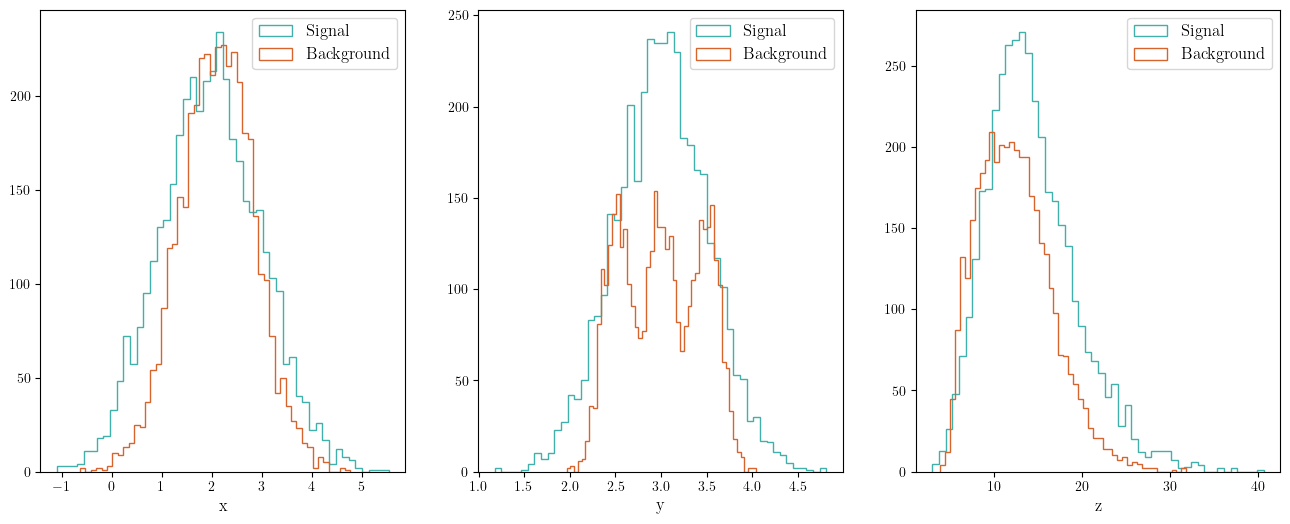

In [21]:
# Plot the training data
fig, ax = plt.subplots(1, 3, figsize = (16, 6))

ax[0].hist(training_signal[0], histtype = 'step', bins = 50, color = colors[0], label = 'Signal')
ax[0].hist(training_background[0], histtype = 'step', bins = 50, color = colors[4], label = 'Background')
ax[0].set_xlabel('x', fontsize = 12)
ax[0].legend(fontsize = 12)

ax[1].hist(training_signal[1], histtype = 'step', bins = 50, color = colors[0], label = 'Signal')
ax[1].hist(training_background[1], histtype = 'step', bins = 50, color = colors[4], label = 'Background')
ax[1].set_xlabel('y', fontsize = 12)
ax[1].legend(fontsize = 12)

ax[2].hist(training_signal[2], histtype = 'step', bins = 50, color = colors[0], label = 'Signal')
ax[2].hist(training_background[2], histtype = 'step', bins = 50, color = colors[4], label = 'Background')
ax[2].set_xlabel('z', fontsize = 12)
ax[2].legend(fontsize = 12)

Text(0.5, 1.0, 'Training Sample')

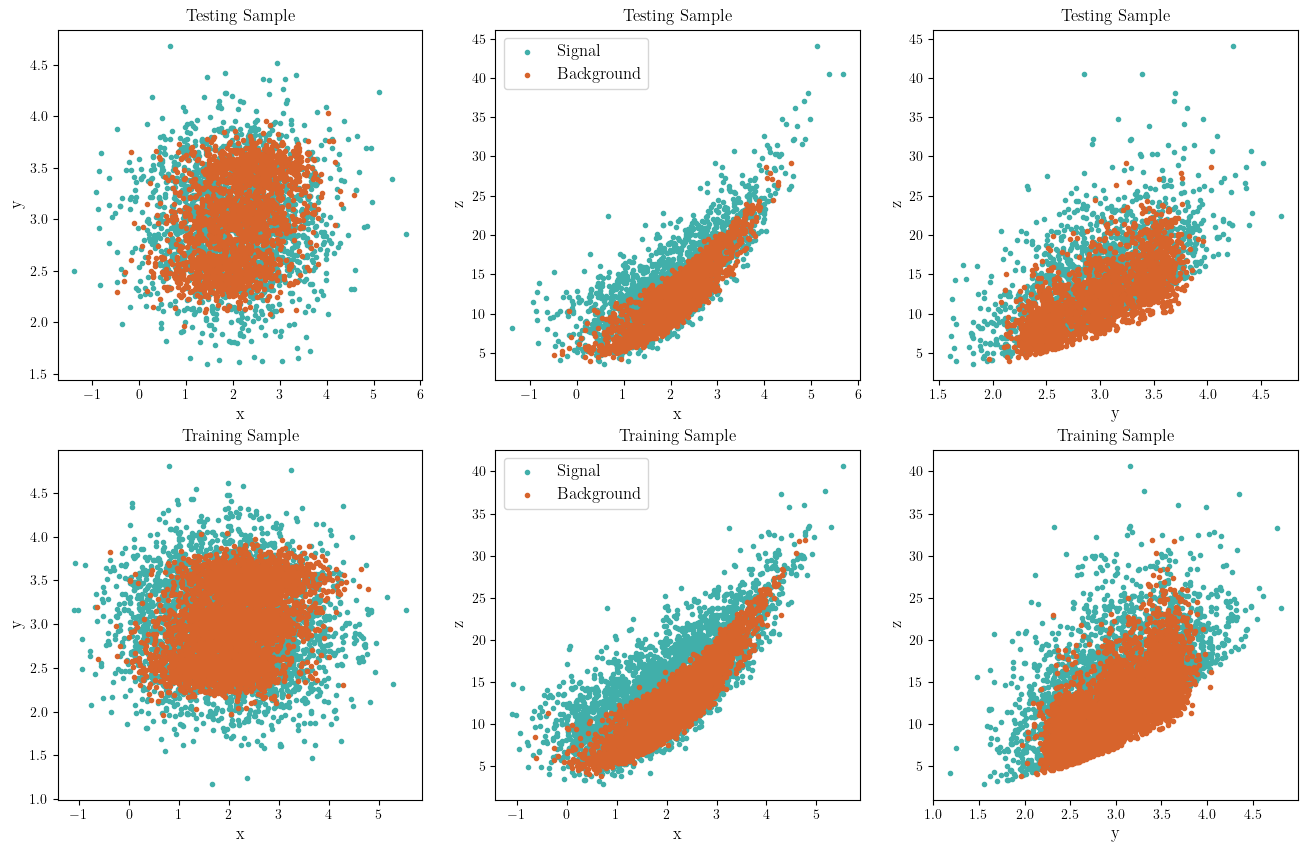

In [31]:
# Making 2D plots
fig, ax = plt.subplots(2, 3, figsize = (16, 10))

ax[0, 0].scatter(test_signal[0], test_signal[1], color = colors[0], marker = '.', label = 'Signal')
ax[0, 0].scatter(test_background[0], test_background[1], color = colors[4], marker = '.', label = 'Background')
ax[0, 0].set_xlabel('x', fontsize = 12)
ax[0, 0].set_ylabel('y', fontsize = 12)
ax[0, 0].set_title('Testing Sample')

ax[0, 1].scatter(test_signal[0], test_signal[2], color = colors[0], marker = '.', label = 'Signal')
ax[0, 1].scatter(test_background[0], test_background[2], color = colors[4], marker = '.', label = 'Background')
ax[0, 1].set_xlabel('x', fontsize = 12)
ax[0, 1].set_ylabel('z', fontsize = 12)
ax[0, 1].legend(fontsize = 12)
ax[0, 1].set_title('Testing Sample')

ax[0, 2].scatter(test_signal[1], test_signal[2], color = colors[0], marker = '.', label = 'Signal')
ax[0, 2].scatter(test_background[1], test_background[2], color = colors[4], marker = '.', label = 'Background')
ax[0, 2].set_xlabel('y', fontsize = 12)
ax[0, 2].set_ylabel('z', fontsize = 12)
ax[0, 2].set_title('Testing Sample')

ax[1, 0].scatter(training_signal[0], training_signal[1], color = colors[0], marker = '.', label = 'Signal')
ax[1, 0].scatter(training_background[0], training_background[1], color = colors[4], marker = '.', label = 'Background')
ax[1, 0].set_xlabel('x', fontsize = 12)
ax[1, 0].set_ylabel('y', fontsize = 12)
ax[1, 0].set_title('Training Sample')

ax[1, 1].scatter(training_signal[0], training_signal[2], color = colors[0], marker = '.', label = 'Signal')
ax[1, 1].scatter(training_background[0], training_background[2], color = colors[4], marker = '.', label = 'Background')
ax[1, 1].set_xlabel('x', fontsize = 12)
ax[1, 1].set_ylabel('z', fontsize = 12)
ax[1, 1].legend(fontsize = 12)
ax[1, 1].set_title('Training Sample')

ax[1, 2].scatter(training_signal[1], training_signal[2], color = colors[0], marker = '.', label = 'Signal')
ax[1, 2].scatter(training_background[1], training_background[2], color = colors[4], marker = '.', label = 'Background')
ax[1, 2].set_xlabel('y', fontsize = 12)
ax[1, 2].set_ylabel('z', fontsize = 12)
ax[1, 2].set_title('Training Sample')

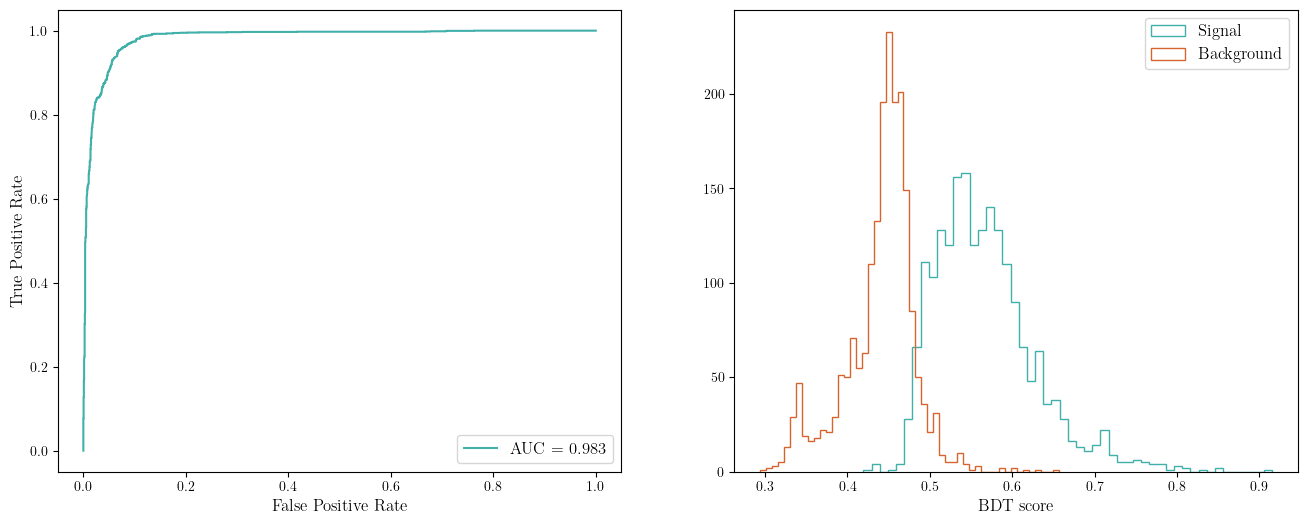

In [45]:
# Training the BDT (Boosted Decision Tree) classifier - getting the BDT score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Training data
X_train = np.array(training_signal)
y_train = np.ones(len(training_signal))
X_train = np.concatenate((X_train, training_background))
y_train = np.concatenate((y_train, np.zeros(len(training_background))))

# Initialize and train BDT
bdt = AdaBoostClassifier(estimator = DecisionTreeClassifier(max_depth = 3), n_estimators = 100, learning_rate = 0.1)
bdt.fit(X_train, y_train)

# Test data
X_test = np.array(test_signal)
y_test = np.ones(len(test_signal))
X_test = np.concatenate((X_test, test_background))
y_test = np.concatenate((y_test, np.zeros(len(test_background))))

# Get BDT scores
bdt_score = bdt.predict_proba(X_test)[:, 1]  # Probability for signal class

# ROC curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, bdt_score)
auc = roc_auc_score(y_test, bdt_score)

# Plotting
fig, ax = plt.subplots(1, 2, figsize = (16, 6))

ax[0].plot(fpr, tpr, color = colors[0], label = 'AUC = {:.3f}'.format(auc))
ax[0].set_xlabel('False Positive Rate', fontsize = 12)
ax[0].set_ylabel('True Positive Rate', fontsize = 12)
ax[0].legend(fontsize = 12)

# BDT score distribution
ax[1].hist(bdt_score[y_test == 1], histtype = 'step', bins = 50, color = colors[0], label = 'Signal')
ax[1].hist(bdt_score[y_test == 0], histtype = 'step', bins = 50, color = colors[4], label = 'Background')
ax[1].set_xlabel('BDT score', fontsize = 12)
ax[1].legend(fontsize = 12)

## Exercise 2 - Boosted Descision Tree (16 variables)

In [47]:
data = pd.read_csv('https://www.nbi.dk/~koskinen/Teaching/data/BDT_16var.txt', delim_whitespace = True, comment = '#', header = None)

print(data)

        0        1        2       3       4       5       6       7       8   \
0        0  14.0163  48.5929 -0.3953 -0.0923 -0.5444  0.7950  0.3092  0.4192   
1        0   7.2650  40.7192 -0.1032  0.3952 -0.7554  0.7484  0.0667  0.6852   
2        1  12.3226  48.2062  0.5697  0.7548 -0.6286 -1.0395  0.4481  0.9034   
3        1  11.2271  52.9859 -0.9173 -0.5173 -0.8481 -0.4088  0.3872  0.5737   
4        2   6.2471  36.2651 -1.6347  0.3801  0.2130  0.9717  0.3859  0.1323   
...    ...      ...      ...     ...     ...     ...     ...     ...     ...   
9995  4997  13.5636  63.8829 -1.9576  0.2517  0.9203  0.7913  0.2492  0.3707   
9996  4998  13.4145  45.5219  0.5900  1.4849 -0.8965 -0.0616  0.7808  0.1696   
9997  4998   7.1508  46.1283  1.8928  1.0025 -0.4604  0.9828  0.2956  0.1471   
9998  4999  13.0181  44.7492 -1.3436  0.1009  0.9387  0.3835  0.7714  0.2790   
9999  4999  11.7440  56.9598 -1.4187  1.8128  0.8961 -0.3284  0.0533  0.3941   

           9       10      11       12 

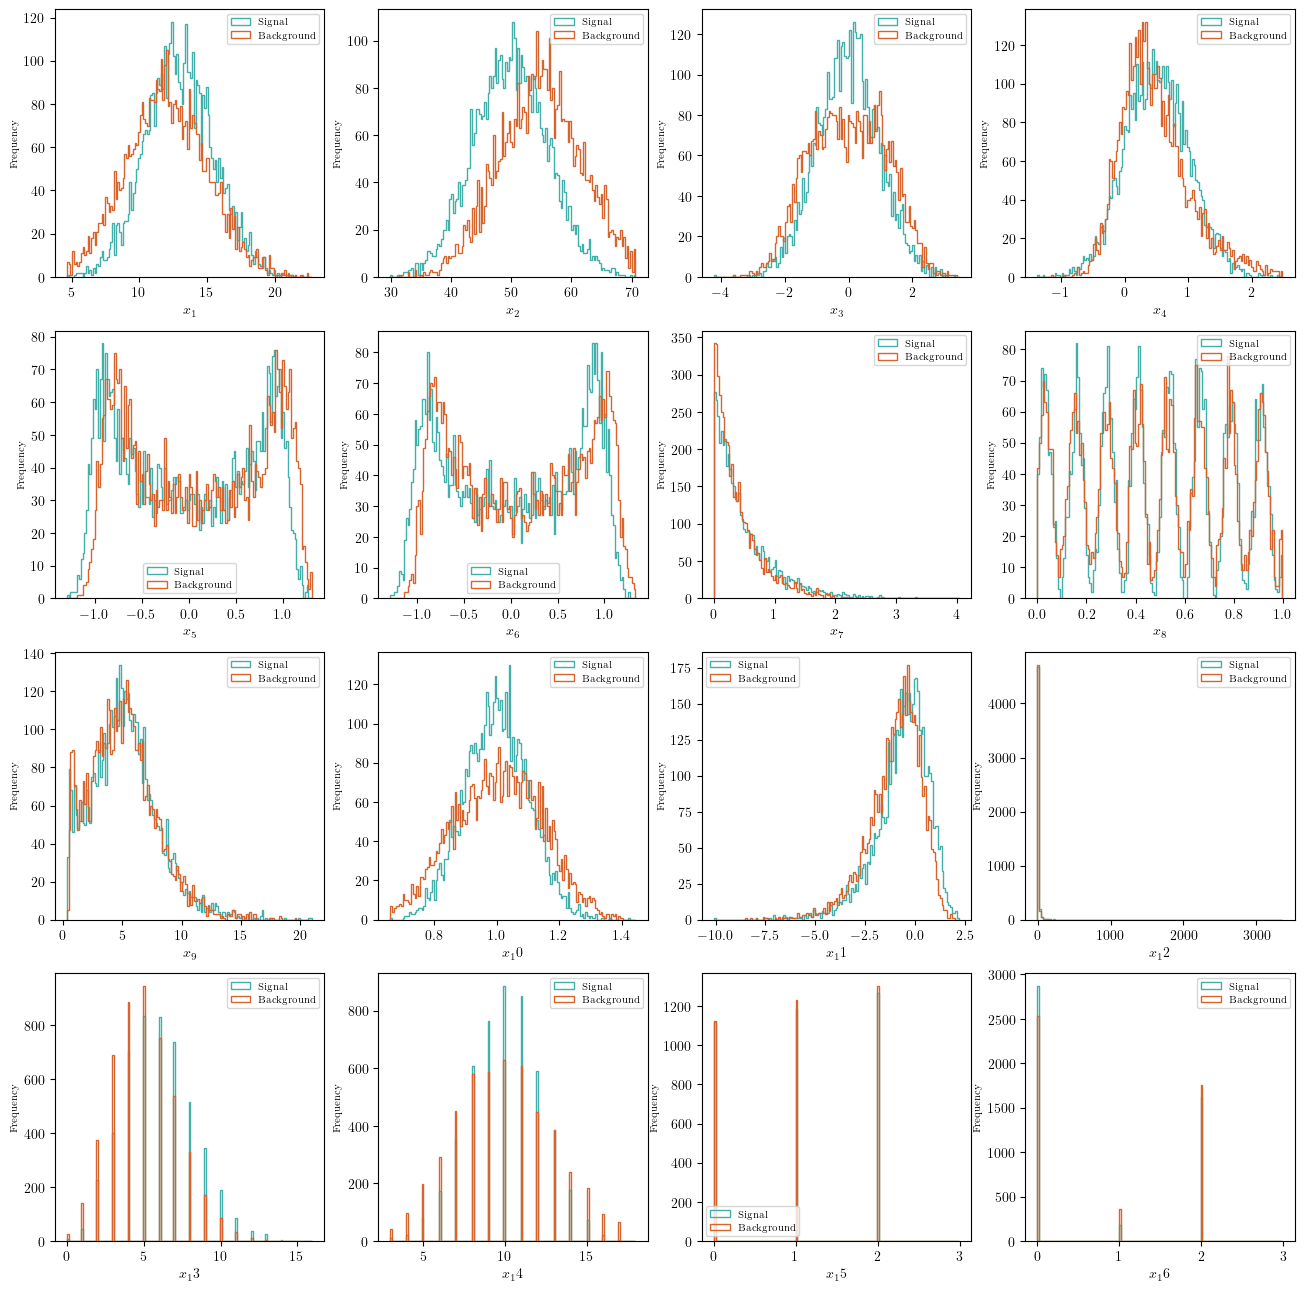

In [67]:
# Seperating each variable into signal and background - even rows are signal, odd rows are background

for i in range(17):
    if i == 0:
        signal = data.iloc[::2, i]
        background = data.iloc[1::2, i]
    else:
        signal = np.column_stack((signal, data.iloc[::2, i]))
        background = np.column_stack((background, data.iloc[1::2, i]))

# Removing the first column, since it just the indexes
signal = signal[:, 1:]
background = background[:, 1:]

# Plotting the data
fig, ax = plt.subplots(4, 4, figsize = (16, 16))

for i in range(4):
    for j in range(4):
        bin_width = 0.5*(signal[:, 4*i + j].max() - signal[:, 4*i + j].min())/np.sqrt(len(signal))
        bins = np.arange(signal[:, 4*i + j].min(), signal[:, 4*i + j].max(), bin_width)
        ax[i, j].hist(signal[:, 4*i + j], histtype = 'step', bins = bins, color = colors[0], label = 'Signal')
        ax[i, j].hist(background[:, 4*i + j], histtype = 'step', bins = bins, color = colors[4], label = 'Background')
        ax[i, j].set_xlabel(r'$x_{}$'.format(4*i + j + 1), fontsize = 10)
        ax[i, j].set_ylabel('Frequency', fontsize = 7)
        ax[i, j].legend(fontsize = 7)


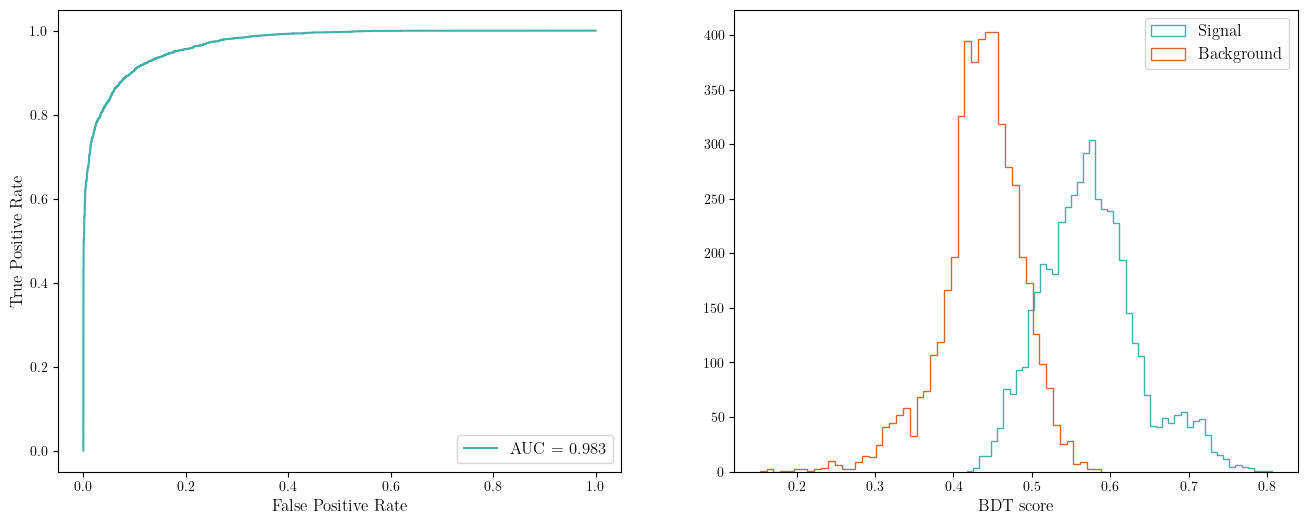

In [69]:
# Training the BDT classifier on the 16 variable data
# Training data
X_train = np.array(signal)
y_train = np.ones(len(signal))
X_train = np.concatenate((X_train, background))
y_train = np.concatenate((y_train, np.zeros(len(background))))

# Initialize and train BDT
bdt = AdaBoostClassifier(estimator = DecisionTreeClassifier(max_depth = 3), n_estimators = 100, learning_rate = 0.1)
bdt.fit(X_train, y_train)

# Test data
X_test = np.array(signal)
y_test = np.ones(len(signal))
X_test = np.concatenate((X_test, background))
y_test = np.concatenate((y_test, np.zeros(len(background))))

# Get BDT scores
bdt_score = bdt.predict_proba(X_test)[:, 1]  # Probability for signal class

# ROC curve
fpr, tpr, _ = roc_curve(y_test, bdt_score)

# Plotting
fig, ax = plt.subplots(1, 2, figsize = (16, 6))

ax[0].plot(fpr, tpr, color = colors[0], label = 'AUC = {:.3f}'.format(auc))
ax[0].set_xlabel('False Positive Rate', fontsize = 12)
ax[0].set_ylabel('True Positive Rate', fontsize = 12)
ax[0].legend(fontsize = 12)

# BDT score distribution
ax[1].hist(bdt_score[y_test == 1], histtype = 'step', bins = 50, color = colors[0], label = 'Signal')
ax[1].hist(bdt_score[y_test == 0], histtype = 'step', bins = 50, color = colors[4], label = 'Background')
ax[1].set_xlabel('BDT score', fontsize = 12)
ax[1].legend(fontsize = 12)